# ============= Engle-Granger Test (Two-Step) =============

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

In [57]:
price_files = [
    "/Users/jameszhao/IMC3/Pre-Comp/Data1/prices_round_1_day_-2.csv",
    "/Users/jameszhao/IMC3/Pre-Comp/Data1/prices_round_1_day_-1.csv",
    "/Users/jameszhao/IMC3/Pre-Comp/Data1/prices_round_1_day_0.csv"
]

# Read and concatenate all price files
price_dfs = [pd.read_csv(f, sep=',') for f in price_files]
all_prices_df = pd.concat(price_dfs, ignore_index=True)

# Save to a new combined CSV
combined_price_path = "/Users/jameszhao/IMC3/Pre-Comp/Data1/prices_combined_days_-2_to_0.csv"
df = pd.read_csv(combined_price_path, sep=',')

In [58]:
products = ['RAINFOREST_RESIN', 'KELP', 'SQUID_INK']

In [59]:
# Filter for the two products
filtered_df = df[df['product'].isin(['KELP', 'SQUID_INK'])]

# Group by timestamp and product, and take the average mid_price
agg_df = filtered_df.groupby(['timestamp', 'product'])['mid_price'].mean().reset_index()

# Pivot to get a time-indexed dataframe
pivot_df = agg_df.pivot(index='timestamp', columns='product', values='mid_price')

# Drop rows with missing values (ensure full overlap of time series)
pivot_df = pivot_df.dropna()

# Extract the series
kelp = pivot_df['KELP']
squid_ink = pivot_df['SQUID_INK']

# 1. Check if Xt and Yt and are I(1): 

In [60]:
def adf_test(series, name):
    result = adfuller(series)
    print(f"ADF Test for {name}:")
    print(f"  Test Statistic = {result[0]}")
    print(f"  p-value = {result[1]}")
    print(f"  Critical Values = {result[4]}")
    print("  --> Stationary" if result[1] < 0.05 else "  --> Non-stationary", "\n")

# Run ADF test on level data
adf_test(kelp, "KELP (level)")
adf_test(squid_ink, "SQUID_INK (level)")

# First differences
adf_test(kelp.diff().dropna(), "KELP (1st difference)")
adf_test(squid_ink.diff().dropna(), "SQUID_INK (1st difference)")


ADF Test for KELP (level):
  Test Statistic = -0.8193692175301027
  p-value = 0.8133661939984123
  Critical Values = {'1%': -3.4310047528604803, '5%': -2.861829361784287, '10%': -2.5669240221402583}
  --> Non-stationary 

ADF Test for SQUID_INK (level):
  Test Statistic = -2.166985898070499
  p-value = 0.2184450575194274
  Critical Values = {'1%': -3.4310065936361585, '5%': -2.861830175207641, '10%': -2.5669244551266304}
  --> Non-stationary 

ADF Test for KELP (1st difference):
  Test Statistic = -47.965550267038985
  p-value = 0.0
  Critical Values = {'1%': -3.4310047528604803, '5%': -2.861829361784287, '10%': -2.5669240221402583}
  --> Stationary 

ADF Test for SQUID_INK (1st difference):
  Test Statistic = -16.861514264626198
  p-value = 1.098737058513747e-29
  Critical Values = {'1%': -3.4310065936361585, '5%': -2.861830175207641, '10%': -2.5669244551266304}
  --> Stationary 



# 2. OLS Regression Xt on Yt to find residual(Mut)

In [61]:
X = sm.add_constant(kelp)
model = sm.OLS(squid_ink, X).fit()
residuals = model.resid

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SQUID_INK   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     692.1
Date:                Mon, 07 Apr 2025   Prob (F-statistic):          1.51e-147
Time:                        18:24:05   Log-Likelihood:                -42482.
No. Observations:               10000   AIC:                         8.497e+04
Df Residuals:                    9998   BIC:                         8.498e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4009.0349     77.464     51.753      0.0

# 3. Test Mut for unit root using Phillips-Ouliaris: 

In [62]:
# This uses the Phillips-Ouliaris approach under the hood
score, pvalue, crit_values = coint(squid_ink, kelp)

print("Phillips-Ouliaris Cointegration Test:")
print(f"Test Statistic: {score}")
print(f"P-value: {pvalue}")
print(f"Critical Values: {crit_values}")
print("  --> Cointegrated" if pvalue < 0.05 else "  --> Not cointegrated")

Phillips-Ouliaris Cointegration Test:
Test Statistic: -2.347158234880172
P-value: 0.3502722748205022
Critical Values: [-3.89753563 -3.33674114 -3.04487419]
  --> Not cointegrated


# 4. Engle-Granger Test (ADF on Residuals): 

In [63]:
print("Engle-Granger Test (ADF on residuals):")
adf_test(residuals, "Residuals from SQUID_INK ~ KELP")

Engle-Granger Test (ADF on residuals):
ADF Test for Residuals from SQUID_INK ~ KELP:
  Test Statistic = -2.3464207835951982
  p-value = 0.1574329291428465
  Critical Values = {'1%': -3.4310065936361585, '5%': -2.861830175207641, '10%': -2.5669244551266304}
  --> Non-stationary 



# 5. Plot of Residuals from Co-integration Regression: 

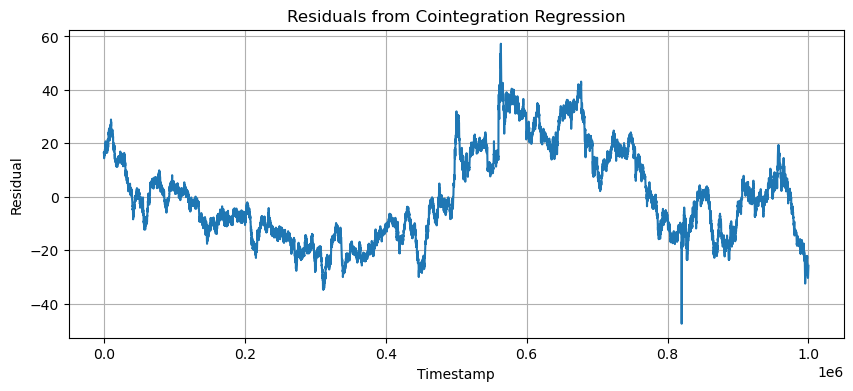

In [64]:
plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("Residuals from Cointegration Regression")
plt.xlabel("Timestamp")
plt.ylabel("Residual")
plt.grid(True)
plt.show()